# LAB · Word2Vec Music Lyrics 1950–2019

**Repositorio de referencia:** `therobotacademy/NLP-Project-Music_1950-2019`  
**Objetivo:** aprender a entrenar y analizar modelos **Word2Vec** y **Doc2Vec** sobre letras de canciones.

Al terminar este notebook deberías ser capaz de:

- entender qué representa un *embedding* de palabra y de documento,
- entrenar un modelo **Word2Vec** sobre un corpus real,
- interpretar similitud semántica entre palabras,
- entrenar **Doc2Vec** para representar canciones completas,
- buscar canciones similares en el espacio vectorial,
- usar embeddings como *features* para una tarea sencilla de clasificación.

## Dataset

El repositorio de referencia utiliza el dataset `tcc_ceds_music.csv`, con canciones entre **1950 y 2019**.  
En el README del repositorio se indica que el dataset completo contiene **28.372 canciones** y **31 columnas**, y que las columnas más relevantes para NLP son `artist_name`, `genre`, `lyrics` y `release_date`. citeturn1view0turn2view0turn3view0

In [ ]:
# Si trabajas en Google Colab, descomenta esta celda.
!pip install -q gensim nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 75.3 MB/s eta 0:00:00


In [ ]:
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)


## 1. Descarga de recursos de NLTK


In [ ]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## 2. Carga del dataset

Puedes trabajar de dos formas:

1. **Local**: si has clonado el repositorio, usa `data/tcc_ceds_music.csv`
2. **Remota**: carga el CSV directamente desde GitHub

El repositorio contiene el fichero `data/tcc_ceds_music.csv`


In [ ]:
LOCAL_PATH = Path("data/tcc_ceds_music.csv")
REMOTE_URL = "https://raw.githubusercontent.com/therobotacademy/NLP-Project-Music_1950-2019/master/data/tcc_ceds_music.csv"

if LOCAL_PATH.exists():
    df = pd.read_csv(LOCAL_PATH)
    source_used = str(LOCAL_PATH)
else:
    df = pd.read_csv(REMOTE_URL)
    source_used = REMOTE_URL

print("Fuente:", source_used)
print("Shape:", df.shape)
df.head(3)


Fuente: data/tcc_ceds_music.csv
Shape: (28372, 31)


,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0


## 3. Exploración inicial

Vamos a localizar las columnas más importantes para este laboratorio y a comprobar que la información textual está disponible.


In [ ]:
df.columns.tolist()


['Unnamed: 0',
 'artist_name',
 'track_name',
 'release_date',
 'genre',
 'lyrics',
 'len',
 'dating',
 'violence',
 'world/life',
 'night/time',
 'shake the audience',
 'family/gospel',
 'romantic',
 'communication',
 'obscene',
 'music',
 'movement/places',
 'light/visual perceptions',
 'family/spiritual',
 'like/girls',
 'sadness',
 'feelings',
 'danceability',
 'loudness',
 'acousticness',
 'instrumentalness',
 'valence',
 'energy',
 'topic',
 'age']

In [ ]:
relevant_cols = [c for c in ["artist_name", "track_name", "genre", "lyrics", "release_date", "len"] if c in df.columns]
print("Columnas relevantes detectadas:", relevant_cols)

df[relevant_cols].head()


Columnas relevantes detectadas: ['artist_name', 'track_name', 'genre', 'lyrics', 'release_date', 'len']


,artist_name,track_name,genre,lyrics,release_date,len
0,mukesh,mohabbat bhi jhoothi,pop,hold time feel break feel untrue convince spea...,1950,95
1,frankie laine,i believe,pop,believe drop rain fall grow believe darkest ni...,1950,51
2,johnnie ray,cry,pop,sweetheart send letter goodbye secret feel bet...,1950,24
3,pérez prado,patricia,pop,kiss lips want stroll charm mambo chacha merin...,1950,54
4,giorgos papadopoulos,apopse eida oneiro,pop,till darling till matter know till dream live ...,1950,48


In [ ]:
print("Número de géneros:", df["genre"].nunique() if "genre" in df.columns else "No disponible")
print("Número de artistas:", df["artist_name"].nunique() if "artist_name" in df.columns else "No disponible")

if "release_date" in df.columns:
    print("Año mínimo:", df["release_date"].min())
    print("Año máximo:", df["release_date"].max())

df["genre"].value_counts().head(10) if "genre" in df.columns else None


Número de géneros: 7
Número de artistas: 5426
Año mínimo: 1950
Año máximo: 2019


,count
genre,
pop,7042
country,5445
blues,4604
rock,4034
jazz,3845
reggae,2498
hip hop,904


## 4. Limpieza básica del dataset

Nos quedamos con las filas que tengan letra y género.  
Después construiremos una **muestra de trabajo** para que el notebook sea más ágil.

Puedes subir `SAMPLE_SIZE` si quieres entrenar con más datos. El dataset contiene 28372 registros


In [ ]:
SAMPLE_SIZE = 5000  # prueba 3000, 5000 o 10000 según tu equipo

work_df = df.copy()

required_cols = ["lyrics", "genre"]
for col in required_cols:
    if col not in work_df.columns:
        raise ValueError(f"Falta la columna requerida: {col}")

work_df = work_df.dropna(subset=["lyrics", "genre"]).copy()
work_df = work_df[work_df["lyrics"].astype(str).str.len() > 50].copy()

if len(work_df) > SAMPLE_SIZE:
    work_df = work_df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)
else:
    work_df = work_df.reset_index(drop=True)

print("Filas de trabajo:", len(work_df))
work_df[["genre", "lyrics"]].head(2)


Filas de trabajo: 5000


,genre,lyrics
0,pop,milkshake bring boys like better damn right be...
1,country,hate music hate music note hate high school go...


## 5. Preprocesado de texto

En este laboratorio aplicaremos un preprocesado **simple y razonable**:

- pasar a minúsculas,
- eliminar caracteres no alfabéticos,
- tokenizar,
- eliminar *stopwords*,
- descartar tokens muy cortos.

No hacemos lematización para mantener el pipeline sencillo y centrado en embeddings distribucionales.


In [ ]:
STOPWORDS = set(stopwords.words("english"))

def normalize_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_lyrics(text: str):
    text = normalize_text(text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in STOPWORDS]
    tokens = [t for t in tokens if len(t) >= 3]
    return tokens


In [ ]:
work_df["tokens"] = work_df["lyrics"].apply(tokenize_lyrics)
work_df["n_tokens"] = work_df["tokens"].apply(len)

# Filtramos canciones con menos de 20 tokens útiles para asegurar calidad en el análisis
work_df = work_df[work_df["n_tokens"] >= 20].reset_index(drop=True)

print("Filas tras tokenización:", len(work_df))
work_df[["genre", "n_tokens", "tokens"]].head(3)


Filas tras tokenización: 4876


,genre,n_tokens,tokens
0,pop,159,"[milkshake, bring, boys, like, better, damn, r..."
1,country,36,"[hate, music, hate, music, note, hate, high, s..."
2,blues,52,"[sister, say, come, wan, say, know, long, draw..."


## 6. ¿Qué entra en Word2Vec?

Word2Vec aprende vectores de palabra a partir de **contextos locales**.  
Aquí cada canción se representa como una lista de tokens y el corpus completo será la colección de esas listas.


In [ ]:
sentences = work_df["tokens"].tolist()

print("Número de canciones usadas como documentos:", len(sentences))
print("Ejemplo de tokens de una canción:")
print(sentences[0][:40])


Número de canciones usadas como documentos: 4876
Ejemplo de tokens de una canción:
['milkshake', 'bring', 'boys', 'like', 'better', 'damn', 'right', 'better', 'teach', 'charge', 'milkshake', 'bring', 'boys', 'like', 'better', 'damn', 'right', 'better', 'teach', 'charge', 'know', 'want', 'thing', 'make', 'guy', 'crazy', 'lose', 'mind', 'wind', 'think', 'time', 'lala', 'lala', 'warm', 'lala', 'lala', 'boys', 'wait', 'lala', 'lala']


## 7. Entrenamiento de Word2Vec

Usaremos arquitectura **Skip-gram** (`sg=1`), que suele funcionar bien para capturar relaciones semánticas cuando el corpus no es gigantesco.

In [ ]:
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,          # 1 = Skip-gram, 0 = CBOW
    epochs=10,
    seed=42
)

print("Tamaño del vocabulario:", len(w2v_model.wv))


Tamaño del vocabulario: 5427


**PARÁMETROS DEL MODELO Word2Vec**

**sentences**: Conjunto de textos usados para entrenar el modelo.
- Debe ser una lista de listas de palabras (tokens). Cada sublista representa un documento o frase, por ejemplo una letra de canción tokenizada.

**vector_size**: Dimensión del embedding de cada palabra.
- En este caso cada palabra se representa con un vector de **100 dimensiones**.
Cuanto mayor sea este valor, mayor capacidad tiene el modelo para capturar relaciones semánticas, pero también aumenta el coste computacional.

**window**: Tamaño de la ventana de contexto.
- Indica cuántas palabras a la izquierda y a la derecha de la palabra objetivo se utilizan para aprender el contexto.
- Con `window=5` el modelo considera hasta **5 palabras antes y 5 después**.

**min_count**: Frecuencia mínima para incluir una palabra en el vocabulario.
- Las palabras que aparecen menos de **5 veces** en el corpus se descartan.
- Esto ayuda a eliminar ruido y reducir el tamaño del vocabulario.

**workers**: Número de hilos de CPU utilizados para el entrenamiento en paralelo.
- Aquí se usan **4 procesos**, lo que acelera el entrenamiento en máquinas con varios núcleos.

**sg**: Define el algoritmo de entrenamiento:
* `sg=1` → **Skip-gram**
* `sg=0` → **CBOW (Continuous Bag of Words)**

Skip-gram aprende a **predecir las palabras del contexto a partir de la palabra central** y suele funcionar mejor con datasets pequeños o palabras raras.

**epochs**: Número de veces que el modelo recorre todo el dataset durante el entrenamiento.
- Con `epochs=10` el corpus se procesa **10 veces**, permitiendo que los embeddings se ajusten progresivamente.

**seed**: Semilla aleatoria utilizada para inicializar los pesos del modelo
- Permite que los resultados sean **reproducibles** cuando se vuelve a entrenar el modelo.

## 8. Exploración del vocabulario


In [ ]:
vocab_preview = w2v_model.wv.index_to_key[:30]
print(vocab_preview)


['know', 'like', 'time', 'come', 'yeah', 'feel', 'heart', 'life', 'away', 'want', 'cause', 'right', 'baby', 'live', 'night', 'leave', 'think', 'tell', 'need', 'world', 'look', 'good', 'break', 'long', 'fall', 'hold', 'gon', 'mind', 'hear', 'say']


## 9. Palabras similares

Una vez entrenado el modelo, podemos preguntar qué palabras aparecen en contextos parecidos.  
Recuerda: **similares en Word2Vec no significa necesariamente sinónimos perfectos**; muchas veces significa *comparten entorno semántico o temático*.


In [ ]:
def show_similar_words(model, word, topn=10):
    if word not in model.wv:
        print(f"'{word}' no está en el vocabulario.")
        return
    result = model.wv.most_similar(word, topn=topn)
    return pd.DataFrame(result, columns=["word", "similarity"])

show_similar_words(w2v_model, "love", topn=10)


,word,similarity
0,occur,0.685794
1,hug,0.684721
2,boopboopadoop,0.684259
3,yeees,0.662472
4,prettiest,0.653848
5,tweet,0.639696
6,vulnerable,0.628278
7,series,0.625800
8,romantic,0.619863
9,playground,0.617689


In [ ]:
for test_word in ["heart", "night", "dance", "baby", "music"]:
    print("\nPalabra consulta:", test_word)
    display(show_similar_words(w2v_model, test_word, topn=5))



Palabra consulta: heart


,word,similarity
0,fascination,0.666902
1,reef,0.663995
2,apart,0.662575
3,bitterness,0.655422
4,favour,0.646631



Palabra consulta: night


,word,similarity
0,dancefloor,0.700083
1,bado,0.677148
2,daytime,0.659012
3,saturday,0.635755
4,boogieboogie,0.632833



Palabra consulta: dance


,word,similarity
0,cramp,0.676924
1,grizzly,0.667348
2,danang,0.626935
3,prance,0.619633
4,thurman,0.618964



Palabra consulta: baby


,word,similarity
0,jacksonville,0.671317
1,whoo,0.625565
2,awfully,0.615383
3,gateway,0.613216
4,rockawhile,0.610309



Palabra consulta: music


,word,similarity
0,choosy,0.663509
1,copyright,0.658808
2,overtones,0.649989
3,publish,0.643792
4,casually,0.616546


## 10. Visualización 2D de palabras con PCA

Reduciremos los embeddings de algunas palabras frecuentes a 2 dimensiones.  
La proyección **no conserva toda la estructura**, pero ayuda a ver agrupaciones locales.


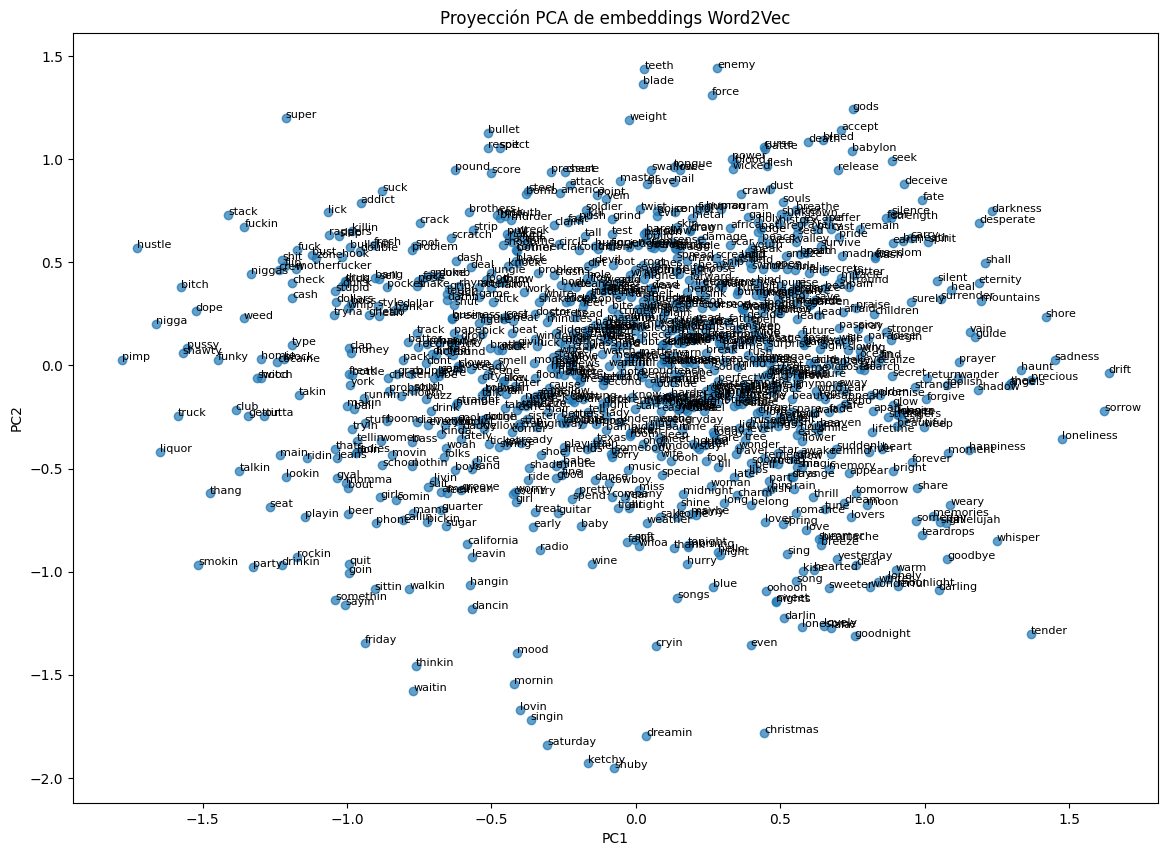

In [ ]:
selected_words = [w for w in w2v_model.wv.index_to_key[:1000] if len(w) > 3][:1000]
word_vectors = np.array([w2v_model.wv[w] for w in selected_words])

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(word_vectors)

plt.figure(figsize=(14, 10))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.7)

for i, word in enumerate(selected_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=8)

plt.title("Proyección PCA de embeddings Word2Vec")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## 11. Embedding de canción a partir de Word2Vec

Word2Vec genera vectores de palabra, no de documento.  
Una estrategia sencilla para representar una canción es **promediar** los embeddings de sus palabras conocidas.

Esto no es Doc2Vec, pero sirve para construir una primera representación vectorial de canciones.


In [ ]:
def average_song_vector(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

work_df["song_vec_w2v"] = work_df["tokens"].apply(lambda toks: average_song_vector(toks, w2v_model))
song_matrix_w2v = np.vstack(work_df["song_vec_w2v"].values)

print(song_matrix_w2v.shape)


(4876, 100)


In [ ]:
song_matrix_w2v[:3,:5]

array([[ 0.02481933,  0.18169406, -0.08709677, -0.00861872, -0.36984247],
       [ 0.24253   , -0.0837663 , -0.20702256,  0.16741602, -0.06388273],
       [ 0.01553916,  0.19362654, -0.13713008, -0.01222896, -0.24915792]],
      dtype=float32)

## 13. Canciones similares usando promedio de Word2Vec


In [ ]:
def most_similar_songs_w2v(row_idx, topn=5):
    query_vec = song_matrix_w2v[row_idx]
    norms = np.linalg.norm(song_matrix_w2v, axis=1) * np.linalg.norm(query_vec)
    sims = np.dot(song_matrix_w2v, query_vec) / np.where(norms == 0, 1e-9, norms)
    best_idx = np.argsort(-sims)
    best_idx = [i for i in best_idx if i != row_idx][:topn]

    cols = [c for c in ["artist_name", "track_name", "genre", "release_date"] if c in work_df.columns]
    result = work_df.loc[best_idx, cols].copy()
    result["similarity"] = sims[best_idx]
    return result

query_id = 0
cols_show = [c for c in ["artist_name", "track_name", "genre", "release_date", "lyrics"] if c in work_df.columns]
display(work_df.loc[[query_id], cols_show[:4]])
most_similar_songs_w2v(query_id, topn=5)


,artist_name,track_name,genre,release_date
0,kelis,milkshake,pop,2003


,artist_name,track_name,genre,release_date,similarity
879,tears for fears,head over heels / broken,pop,1985,0.875446
3791,phish,"ob-la-di, ob-la-da",blues,1994,0.826004
3615,thin lizzy,philomena,blues,1974,0.817798
3748,rambutan jam band,doing what they taught us,reggae,2014,0.816022
3814,kids see ghosts,4th dimension,pop,2018,0.812831
